In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv("./gene_expression.csv")
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
knn = KNeighborsClassifier()
from sklearn.pipeline import Pipeline

oprations = [
    ("scaler",scaler),
    ("knn",knn)
]
pipe = Pipeline(oprations)



In [2]:
from sklearn.model_selection import GridSearchCV

In [3]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [4]:
k_values = list(range(1,31))
param_grid = {"knn__n_neighbors":k_values}
grid_search = GridSearchCV(pipe,param_grid,cv=5,scoring="accuracy")
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score 
prted = grid_search.predict(X_test)
acc = accuracy_score(y_test,prted)
acc

0.9466666666666667

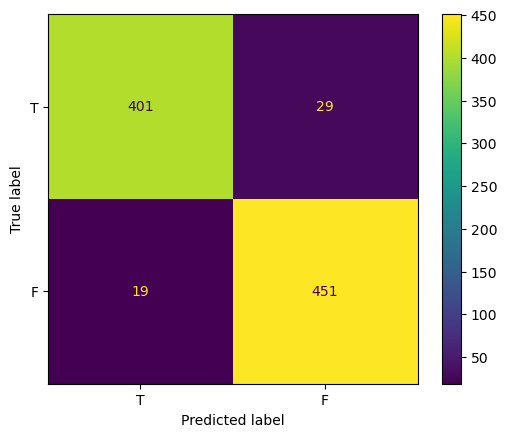

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test,prted,labels=[1,0],
                                        display_labels=["T","F"])

# 探索支持向量機（Support Vector Machines, SVM）

**注意：在這個範例中，我們將探討算法，所以我們將跳過數據標準化和訓練/測試拆分，而是看看各種參數如何改變SVM（在分類中最容易視覺化效果）**

[關於SVM的優秀論文鏈接](http://citeseerx.ist.psu.edu/viewdoc/download;jsessionid=4448154647BC7B10C991CEF2236BBA38?doi=10.1.1.114.4288&rep=rep1&type=pdf)
* A tutorial on support vector regression by ALEX J. SMOLA and BERNHARD SCHOLKOPF

## SVM - 分類

### 簡介
支持向量機（Support Vector Machines，SVM）是一種監督學習模型，通常用於分類和回歸分析。SVM的目標是找到一個最佳的超平面來將數據點分開，這個超平面可以最大化邊界（即支持向量）。

### 參數
在探索SVM的過程中，有幾個重要的參數需要理解和調整：
1. **核函數（Kernel Function）**：核函數將低維空間的數據轉換到高維空間，使得數據在高維空間中更容易分離。常見的核函數包括線性核、多項式核和高斯徑向基核（RBF核）。

2. **C參數（正則化參數）**：C值控制的是誤分類的懲罰程度。較小的C值會產生一個更平滑的決策邊界，但可能會容忍更多的誤分類；較大的C值會努力正確分類所有訓練樣本，但可能導致過擬合。

3. **γ參數（gamma）**：γ參數適用於多項式核和RBF核。γ值決定了單個訓練樣本的影響範圍。較大的γ值會使得決策邊界更加複雜，較小的γ值會使得決策邊界更平滑。

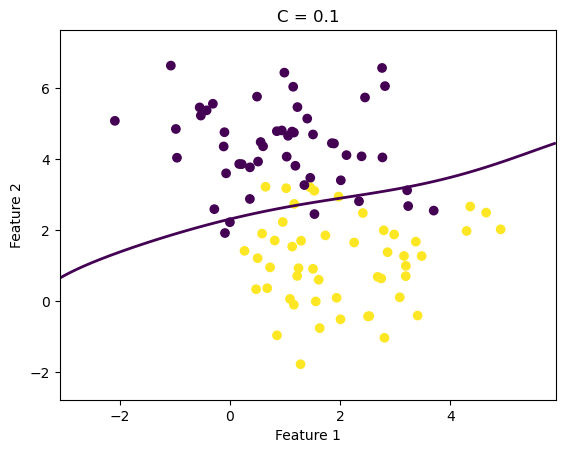

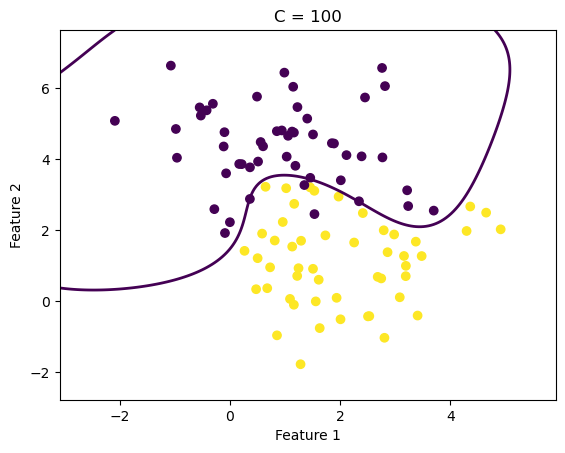

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

# Compare decision boundaries for small and large C values
#gamma='scale' 會根據資料特徵的「維度」和「變異程度」自動調整，
for C in [0.1, 100]:
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X, y)
    
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contour(xx, yy, Z, levels=[0], linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f'C = {C}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


In [9]:
df = pd.read_csv("mouse_viral_study.csv")
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

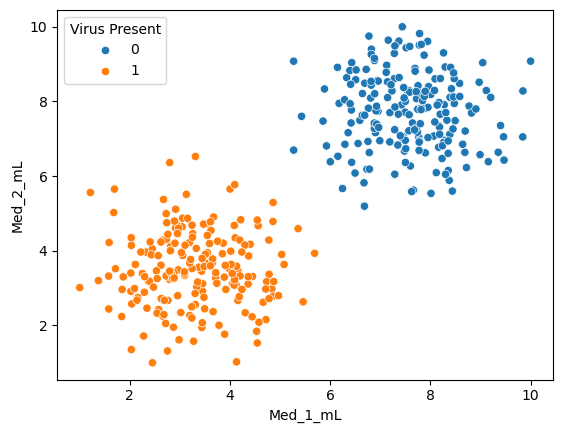

In [10]:
sns.scatterplot(x="Med_1_mL",y="Med_2_mL",hue="Virus Present",data=df)

In [11]:
from sklearn.svm import SVC # Supprt Vector Classifier
import warnings
# 忽略 scikit-learn 的 UserWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [14]:
y = df["Virus Present"]
X = df.drop("Virus Present",axis=1)

In [15]:
model = SVC(kernel="linear",C=1000)
model.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


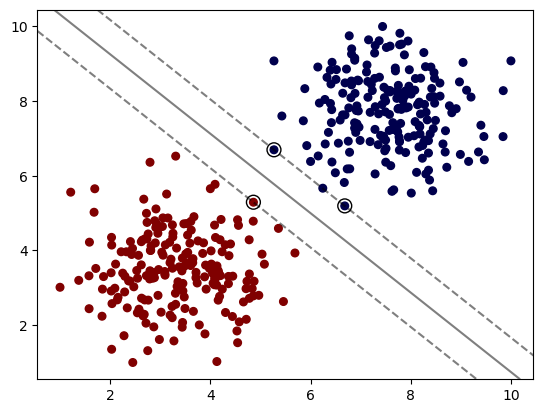

In [17]:
from svm_margin_plot import plot_svm_boundary
plot_svm_boundary(model,X,y)

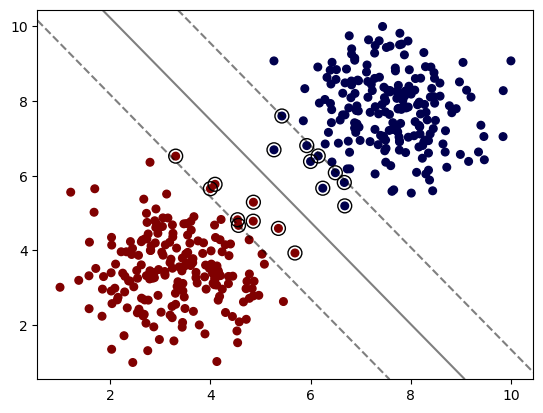

In [18]:
model = SVC(kernel="linear",C=0.05)
model.fit(X,y)
plot_svm_boundary(model,X,y)

## gamma值的理解

- **gamma值越大**：
  - 模型會更加關注訓練數據中非常接近的資料點。
  - 因為模型更緊密地擬合這些局部數據，所以可能會導致過擬合（overfitting）。

- **gamma值越小**：
  - 模型會考慮更廣泛的資料範圍，訓練時更多地關注整體數據分佈。
  - 因此，模型更均勻地適應數據，但可能會導致欠擬合（underfitting），因為它忽略了數據中的一些細節。

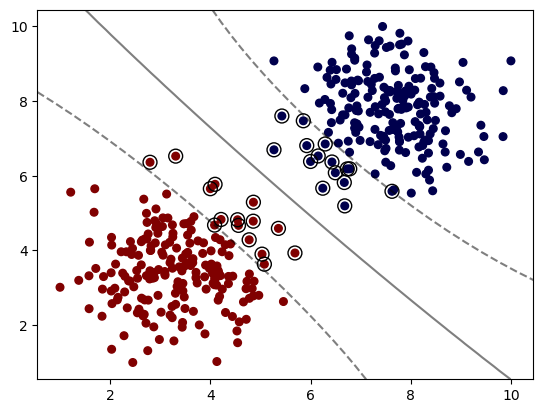

In [20]:
model = SVC(kernel="rbf",C=1,gamma=0.01)
model.fit(X,y)
plot_svm_boundary(model,X,y)

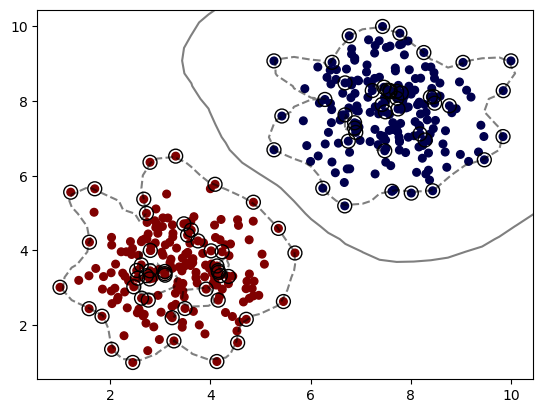

In [21]:
model = SVC(kernel="rbf",C=1,gamma=1)
model.fit(X,y)
plot_svm_boundary(model,X,y)

## 網格搜索

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC

In [23]:
X_np, y_np = make_moons(n_samples=300,
                         noise=0.12, 
                         random_state=42)
monX = pd.DataFrame(X_np,columns=["x1","x2"])
mony = pd.Series(y_np)

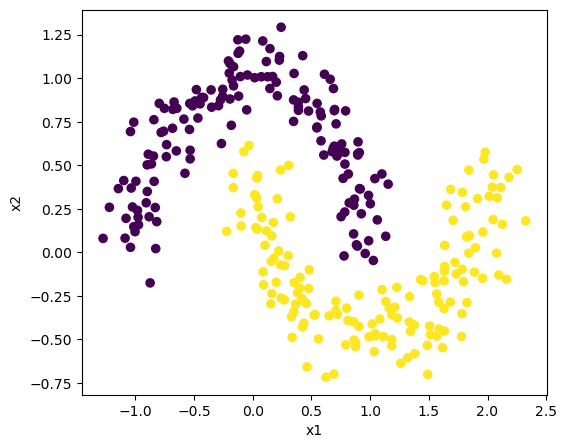

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(monX["x1"],monX["x2"],c=mony,s=35)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [25]:
# 1) 要測的參數範圍（常用：用 10 倍去試）
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]  # 固定用 rbf，因為你本來就是 rbf
}

In [28]:
#根據資料的分類比例切 例如 1分類 70% 0分類 30%每次切分盡力這個比例 
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=42   )
grid = GridSearchCV(estimator=SVC(),
                    param_grid=param_grid,
                    scoring="accuracy",cv=cv)

In [29]:
grid.fit(monX,mony)
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
1.0


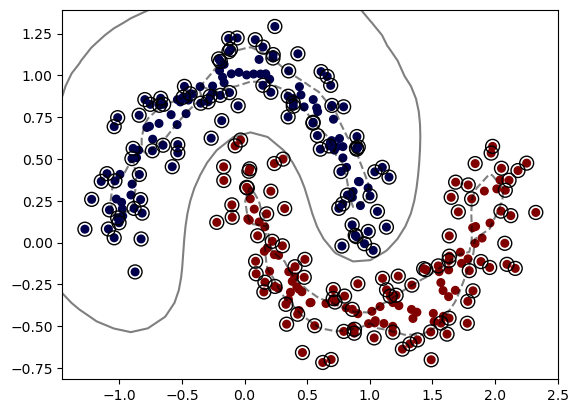

In [30]:
bast_model = grid.best_estimator_
plot_svm_boundary(bast_model,monX,mony)

我們將使用“Palmer Penguins”數據集，這個數據集足夠簡單，可以幫助我們完全理解超參數改變如何影響分類結果。
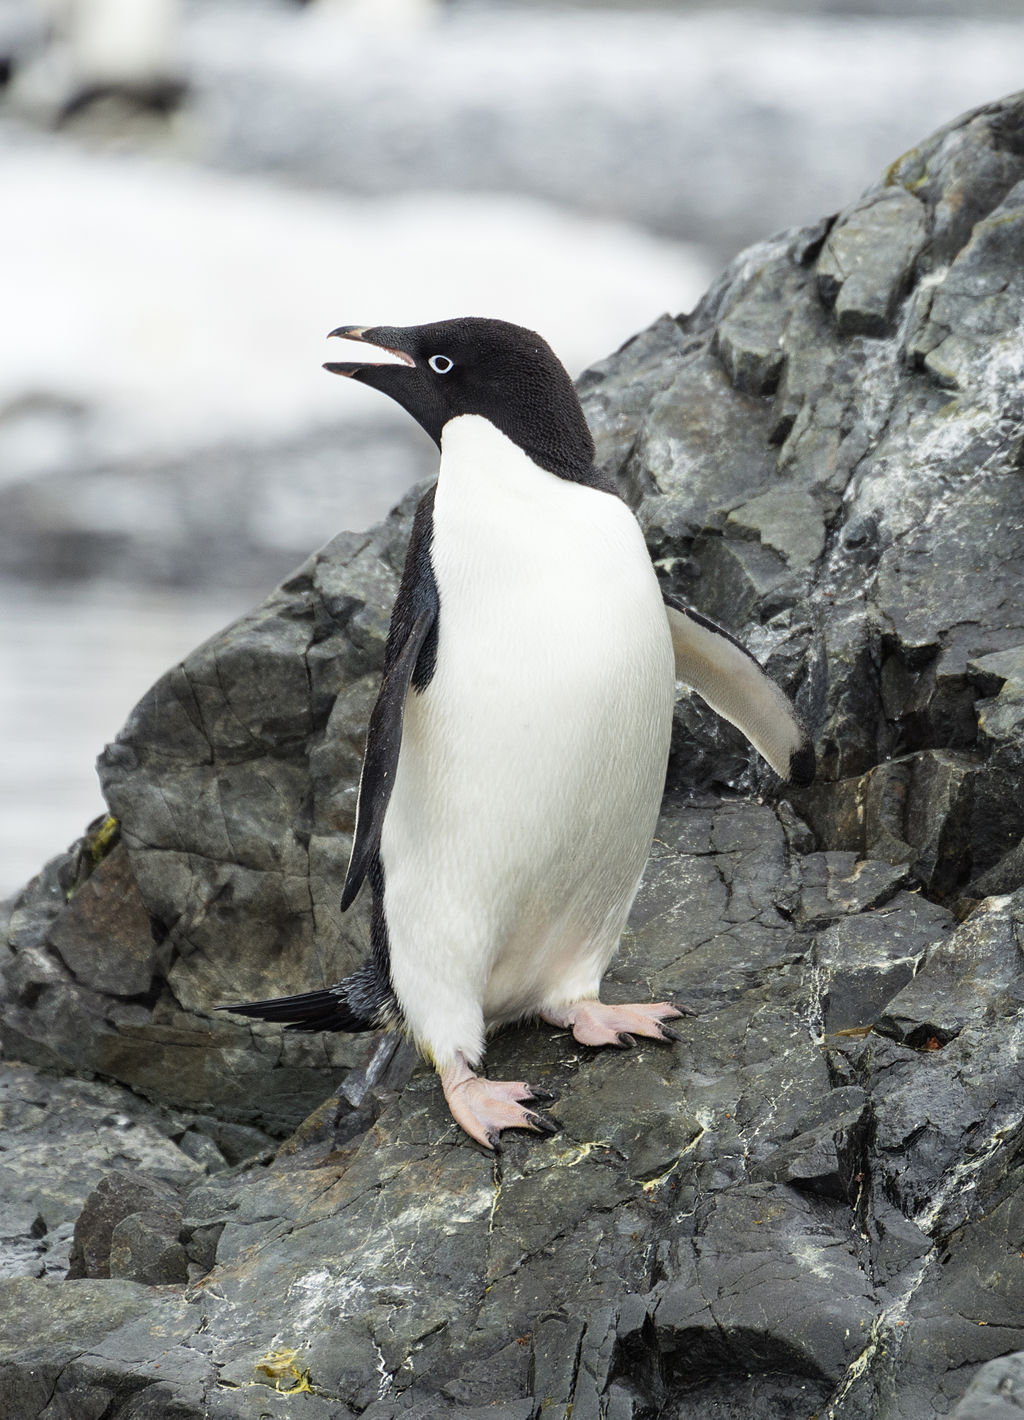

些數據由Dr. Kristen Gorman和Palmer Station，南極LTER（一個長期生態研究網絡的成員）收集並提供。

Gorman KB, Williams TD, Fraser WR (2014) 《Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis)》。PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081



* penguins_size.csv：簡化的數據來自原始企鵝數據集。包含變量：

    * species：企鵝物種（帽帶企鵝、阿德利企鵝或紐帶企鵝）
    * culmen_length_mm：嘴峰長度（毫米）
    * culmen_depth_mm：嘴峰深度（毫米）
    * flipper_length_mm：鰭長度（毫米）
    * body_mass_g：體重（克）
    * island：在Palmer群島（南極洲）的島嶼名稱（Dream, Torgersen或Biscoe）
    * sex：企鵝性別

註：嘴峰是“鳥喙的上脊”

**我們的目標是創建一個模型，該模型可以根據物理屬性幫助預測企鵝的物種，然後我們可以使用該模型幫助研究人員在現場分類企鵝，而無需經驗豐富的生物學家**


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [33]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [34]:
df.dropna(inplace=True)
df.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [35]:
df["sex"].unique()

<ArrowStringArray>
['MALE', 'FEMALE', '.']
Length: 3, dtype: str

In [36]:
df = df[df["sex"] != "."]

In [37]:
df["sex"].unique()

<ArrowStringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

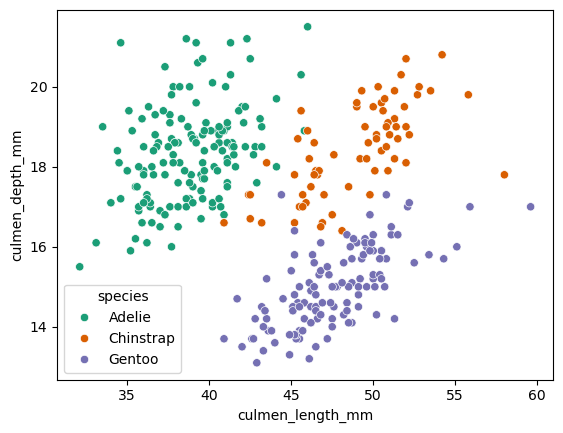

In [38]:
sns.scatterplot(x="culmen_length_mm",y='culmen_depth_mm',data=df,hue="species",palette="Dark2")

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


In [40]:
X = pd.get_dummies(df.drop('species',axis=1),drop_first=True)
y = df["species"]

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [42]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [43]:
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [44]:
base_pred = model.predict(X_test)  

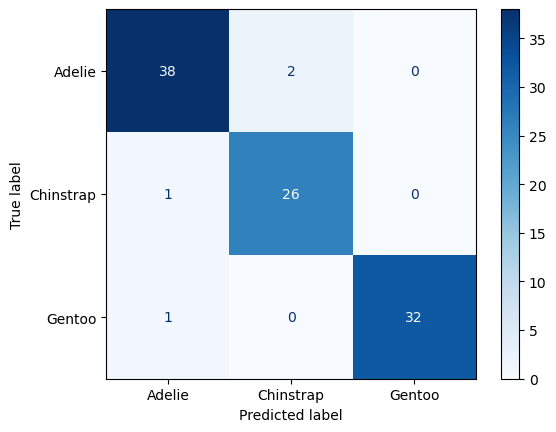

In [45]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
cm  = confusion_matrix(y_test,base_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Visualize the Tree

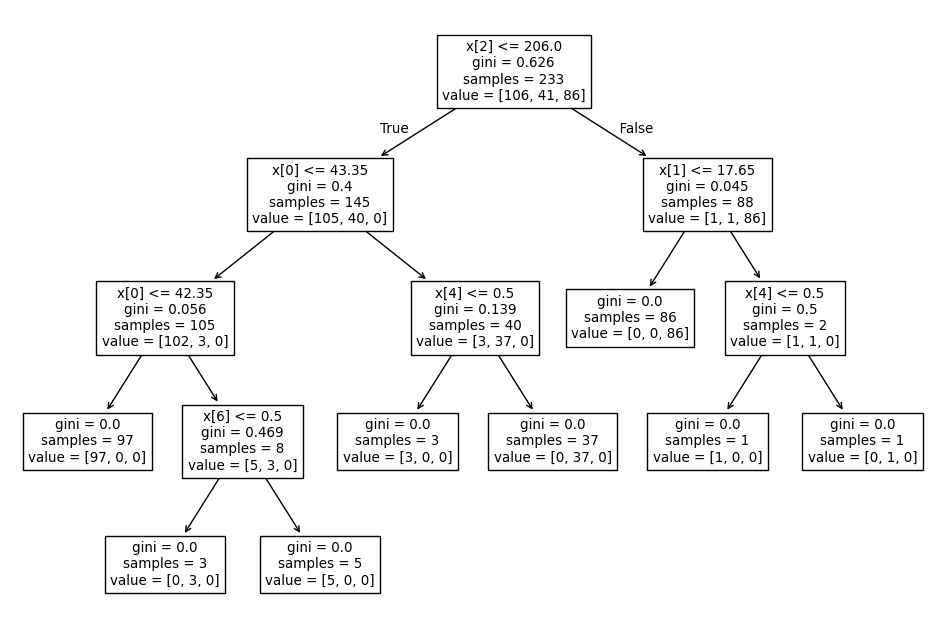

In [46]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model)
plt.show()

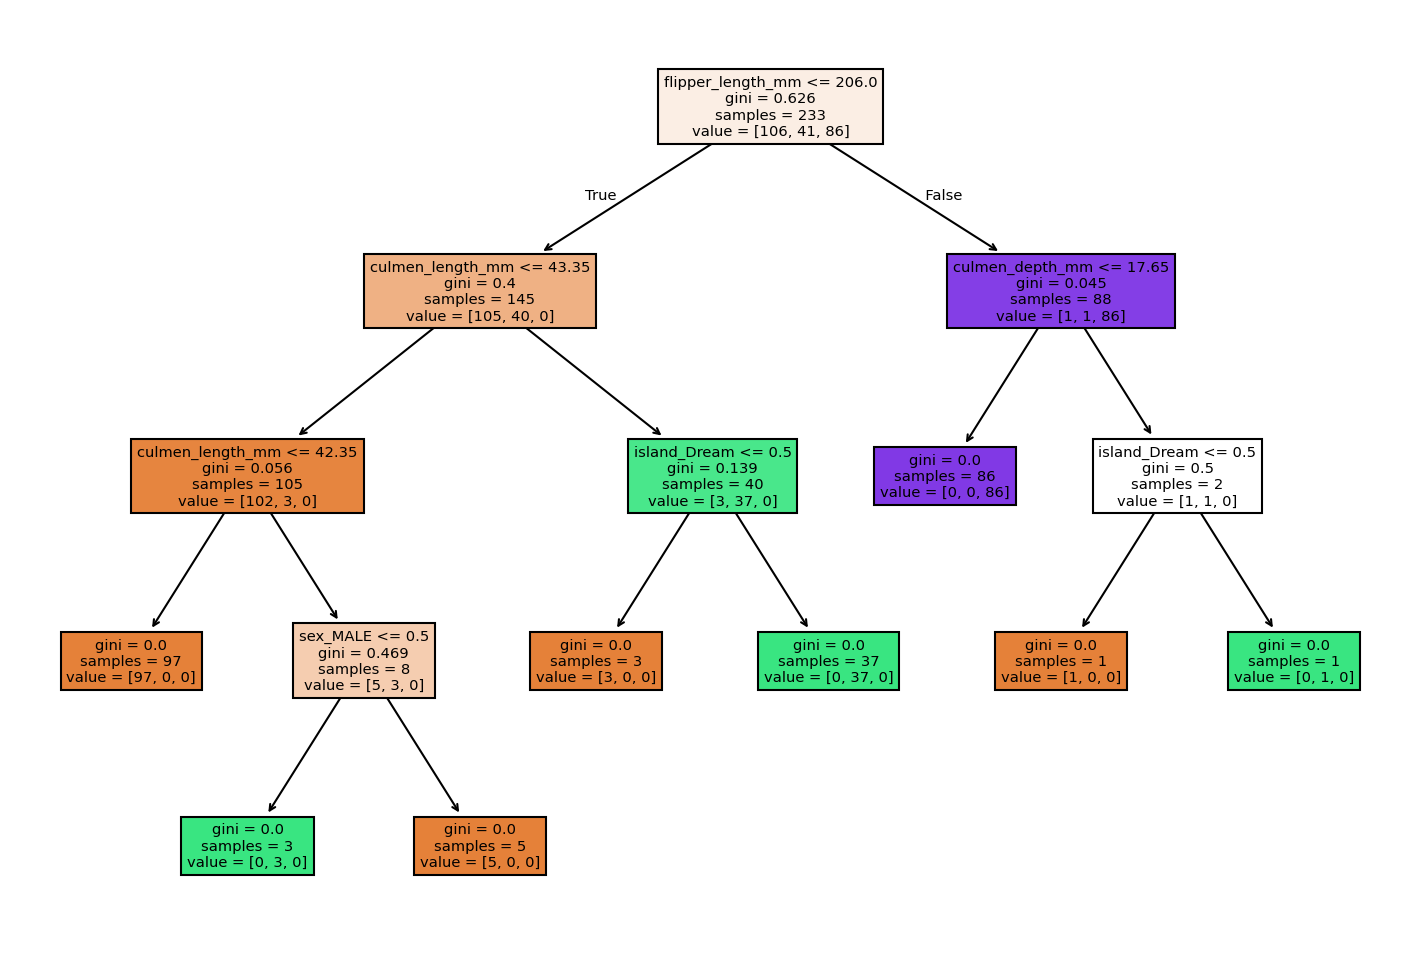

In [47]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns)
plt.show()

In [48]:
accuracy_score(y_test,base_pred)

0.96

In [49]:
from sklearn.ensemble import RandomForestClassifier
# n_estimators 決策樹的數量
model = RandomForestClassifier(n_estimators=103,random_state=101)
model.fit(X_train,y_train)
preds = model.predict(X_test) 

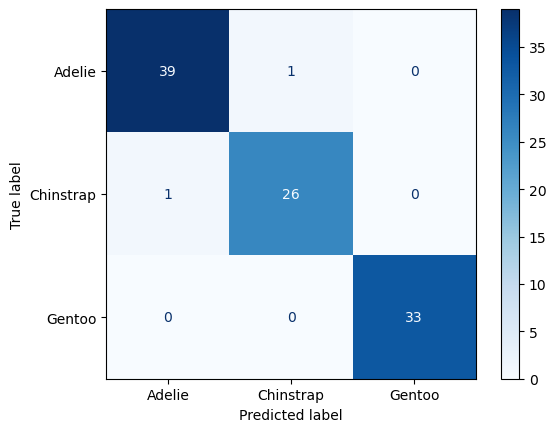

In [50]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score 
cm  = confusion_matrix(y_test,preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [51]:
accuracy_score(y_test,preds)

0.98

## 單純貝氏分類法

## CountVectorizer

在使用 CountVectorizer 時，
指定 stop_words='english' 會自動移除英文中的常見停用詞（stop words），
例如 "this" 和 "is"。停用詞是一些在文本分析中不具有區分度的常見單詞，例如冠詞、連詞和一些代詞。這些單詞通常對文本的主題或意圖沒有太大的貢獻，所以在計算特徵時會被移除。

In [52]:
from sklearn.feature_extraction.text import TfidfTransformer,TfidfVectorizer,CountVectorizer
text = ['This is a line',

           "This is another line",
           
       "Completely different line"]

In [53]:
cv = CountVectorizer(stop_words="english")
counts =  cv.fit_transform(text)
counts.todense()

matrix([[0, 0, 1],
        [0, 0, 1],
        [1, 1, 1]])

In [54]:
cv.vocabulary_

{'line': 2, 'completely': 0, 'different': 1}


簡單來說，`TfidfTransformer` 就是一個「幫字詞打分數」的工具，它會把你原本的詞頻（也就是某個字在文件中出現了多少次）轉換成更有區別度的「TF–IDF 分數」。

1. **TF（Term Frequency，詞頻）**：衡量一個詞在一篇文件裡出現的頻率。出現越多，原始分數越高。
2. **IDF（Inverse Document Frequency，逆文件頻率）**：衡量一個詞在整個語料庫（所有文件）中有多「罕見」。如果一個詞在很多文件裡都出現（像「的」、「是」這種常見字），它的 IDF 會很低；只有少數文件裡才出現的詞（像「電腦視覺」、「隨機森林」）IDF 會比較高。

`TfidfTransformer` 會把這兩者「相乘」：

$$
\text{TF–IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{DF}(t)}
$$

* $t$ 是詞，$d$ 是文件
* $N$ 是文件總數，$\text{DF}(t)$ 是包含詞 $t$ 的文件數

**為什麼要這麼做？**

* 把在特定文件中很重要（頻繁出現），但在整體語料庫中又很少見的詞，打上高分。
* 把那些雖然在文件裡出現很多次，卻在所有文件裡都常見的詞，打上低分。

這樣一來，你在做後續機器學習或相似度比對時，就能更容易「抓到」那些真正能區分文件意義的關鍵字，而不是被高頻的「停用詞」干擾。


**舉例TF-IDF應用**

我會根據用戶問題提供一個實際的例子，用來解釋TF-IDF。這方面，我可以探討像是“蘋果手機”這類專有名詞，出現在某些文檔中頻繁卻重要性較高的詞彙；而“的”這類中文常見停用詞，雖然出現頻繁，但TF-IDF值會較低。為了更清楚，我可以展示一個小範例，通過簡單的數字來說明這些詞彙在TF-IDF計算中的表現。

**說明TF-IDF範例**

我可以舉兩個例子來區分“常出現但不重要”和“常出現但重要”的詞彙。“的”在所有文檔中都會出現，因此IDF很低，TF高，但TF-IDF低；而“蘋果手機”在第一篇文檔中出現兩次，其他文檔比較少，也因此TF和IDF都較高，因此TF-IDF較高。簡單來說，“蘋果手機”在特定文檔中出現頻繁且重要，而“的”雖然常見卻對於區分意圖的文檔來說沒有重要性。

**解釋TF-IDF範例**

“常出現但不重要”如“的”這樣的停用詞，通常在所有文檔中頻繁出現，IDF很低，因此TF-IDF並不高。而如“Quibli”，它在特定領域的文章中頻繁出現但在其他地方很少見，IDF則高，TF-IDF就會很高，顯示它對該文章很重要。另外，如果在不同運動領域的文章中，像“湖人”這樣的詞彙可能顯得很重要，若只在拳擊文章中出現，每篇都帶來高TF-IDF。


已思考 29 秒鐘


以下用一個簡單的「籃球賽報導」小語料庫舉例，說明兩類「常出現」的詞：

1. **常出現但不重要**（停用詞／泛用詞）
2. **常出現且重要**（能區分本文主題的關鍵詞）

---

## 語料庫（共 3 篇短文）

* **Doc1（湖人隊比賽）**

  > 「湖人 在 今晚 的比賽 中 以 102：98 戰勝 勇士，球員的表現 出色。」

* **Doc2（勇士隊新聞）**

  > 「勇士 球隊球員今季新秀的表現 穩定，但 在 防守 端 仍 有 改善 空間。」

* **Doc3（一般體育新聞）**

  > 「今年的體育 賽事 因 為 天候 的影響 而 延期，眾多 球迷 只能 在 電視 前 觀賽。」

設 $N=3$。計算幾個詞在 **Doc1** 中的 TF–IDF：

|  詞彙 | Doc1 中 TF | DF（出現過的文件數） | IDF = $\log\frac{N}{\text{DF}}$ |  TF–IDF = TF × IDF |         分類        |
| :-: | :-------: | :---------: | :-----------------------------: | :----------------: | :---------------: |
|  的  |     2     |      3      |       $\log\frac{3}{3}=0$       |    $2\times0=0$    |    常見停用詞 → 不重要    |
|  球員 |     1     |      2      |   $\log\frac{3}{2}\approx0.18$  | $1\times0.18=0.18$ | 常見詞，但多篇都有提 → 不太區分 |
|  湖人 |     1     |      1      |   $\log\frac{3}{1}\approx1.10$  | $1\times1.10=1.10$ |     本文主題 → 重要     |
|  戰勝 |     1     |      1      |   $\log\frac{3}{1}\approx1.10$  | $1\times1.10=1.10$ |     本文事件 → 重要     |

* **「的」**：停用詞，雖然在 Doc1 出現 2 次（TF 高），但因為在所有 3 篇都出現（DF=3），IDF=0，最終 TF–IDF=0 → 不重要。
* **「球員」**：在 Doc1 出現 1 次，但同時 Doc2 也提到（DF=2），IDF 約 0.18，所以 TF–IDF 也很低 → 雖「常出現」，卻不具辨別力。
* **「湖人」、「戰勝」**：都只在 Doc1 出現（DF=1），IDF≈1.10，TF–IDF≈1.10 → 不僅常出現，而且是報導的核心詞，分數高 → 重要。

---

### 小結

* **常出現但不重要**：像「的」、「球員」，即使在一篇文中頻繁出現，因為在多篇文都會出現，IDF 低、TF–IDF 低 → 適合視為停用或次要詞。
* **常出現且重要**：像「湖人」、「戰勝」，在目標文件中頻繁出現，但在整體語料庫中少見，IDF 高、TF–IDF 高 → 最能凸顯該文件獨特內容。

### The Data

Source: https://www.kaggle.com/crowdflower/twitter-airline-sentiment?select=Tweets.csv

This data originally came from Crowdflower's Data for Everyone library.

As the original source says,

A sentiment analysis job about the problems of each major U.S. airline. Twitter data was scraped from February of 2015 and contributors were asked to first classify positive, negative, and neutral tweets, followed by categorizing negative reasons (such as "late flight" or "rude service").

#### The Goal: Create a Machine Learning Algorithm that can predict if a tweet is positive, neutral, or negative. In the future we could use such an algorithm to automatically read and flag tweets for an airline for a customer service agent to reach out to contact.


### 資料來源

來源：https://www.kaggle.com/crowdflower/twitter-airline-sentiment?select=Tweets.csv

這些資料最初來自 Crowdflower 的「Data for Everyone」資料庫。

根據原始來源所述，

這是一個關於美國主要航空公司問題的情感分析工作。Twitter 數據是從 2015 年 2 月收集的，並且請求貢獻者首先將推文分類為正面、負面和中性，然後再分類負面原因（例如「航班延誤」或「服務粗魯」）。

#### 目標：建立一個機器學習算法來預測推文是正面、中性還是負面。在未來，我們可以使用這樣的算法自動閱讀並標記航空公司的推文，讓客服人員聯繫客戶。

In [55]:
df = pd.read_csv("airline_tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: xlabel='airline', ylabel='count'>

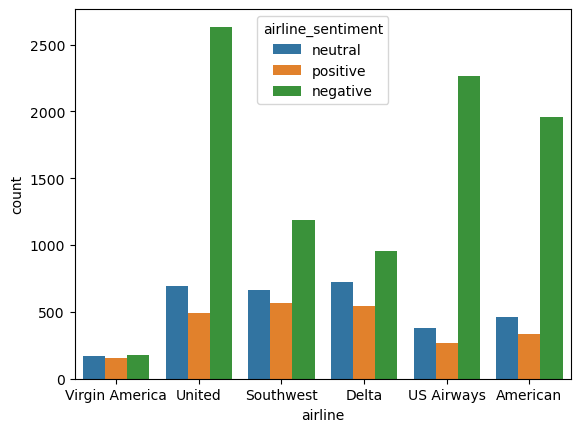

In [56]:
sns.countplot(data=df,x="airline",hue="airline_sentiment")

In [57]:
y = df["airline_sentiment"]
X = df["text"]

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [60]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf.fit(X_train)
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [61]:
from sklearn.naive_bayes import MultinomialNB
#給定特徵 X（例如一段文字），預測它的標籤 y（例如情緒正面或負面）。
#整份文件中，某個詞如果在負面情緒的訓練資料中常出現、重要性高，
#那未來看到這個詞時，模型就會偏向判它為負面。
nb = MultinomialNB()
nb.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [62]:
test = tfidf.transform(["@SouthwestAir thanks! Very "])
pred = nb.predict(test)
print(pred)

['positive']
